In [8]:
!pip3 install matplotlib

### 1. Import Dependencies

In [10]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Basic Processing

In [5]:
df = pd.read_csv("/Users/hevindutilakasena/Bootcamp ZuuCrew/EDA/data/processed/Missing_Values_Handled.csv")
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.00,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41.00,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42.00,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,38.91,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43.00,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 11)

### 3. Outlier Detection Techniques

#### 3.1 Distribution Plots

In [13]:
categorical_columns = [
    "Geography",
    "Gender",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts",
    "Exited"
]

numerical_columns = ["Age", "Tenure", "Balance", "EstimatedSalary", "CreditScore", "NumOfProducts"]

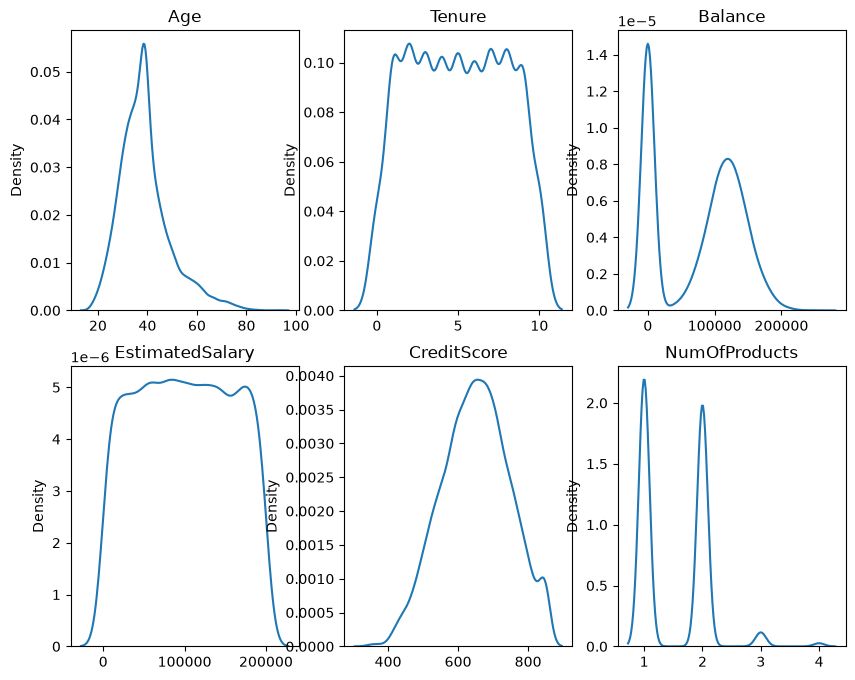

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(10,8))
axes = axes.flatten()
for idx, col in enumerate(numerical_columns):
    sns.kdeplot(data=df[col], ax = axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

plt.show()

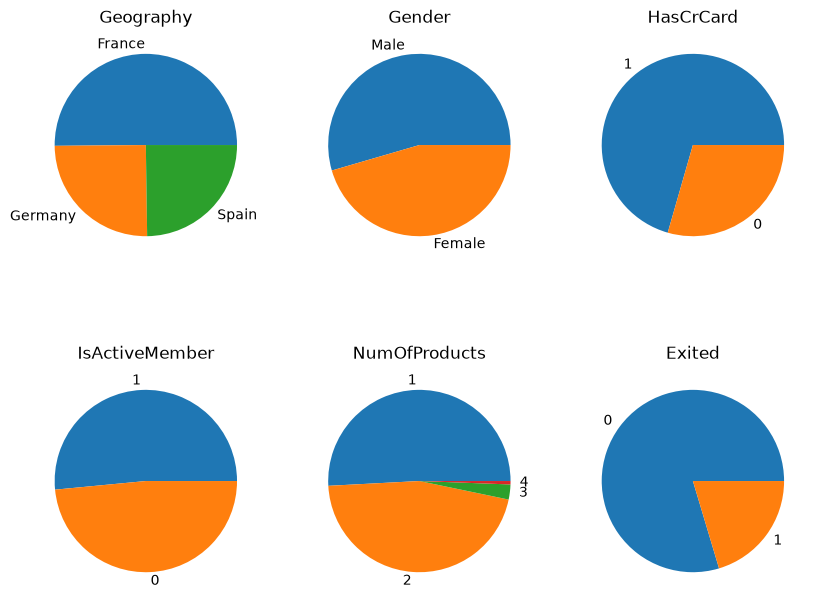

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(10,8))
axes = axes.flatten()
for idx, col in enumerate(categorical_columns):
    df[col].value_counts().plot(
        kind='pie',
        ax=axes[idx]
    )
    axes[idx].set_title(col)
plt.show()

#### 3.2 Box Plots

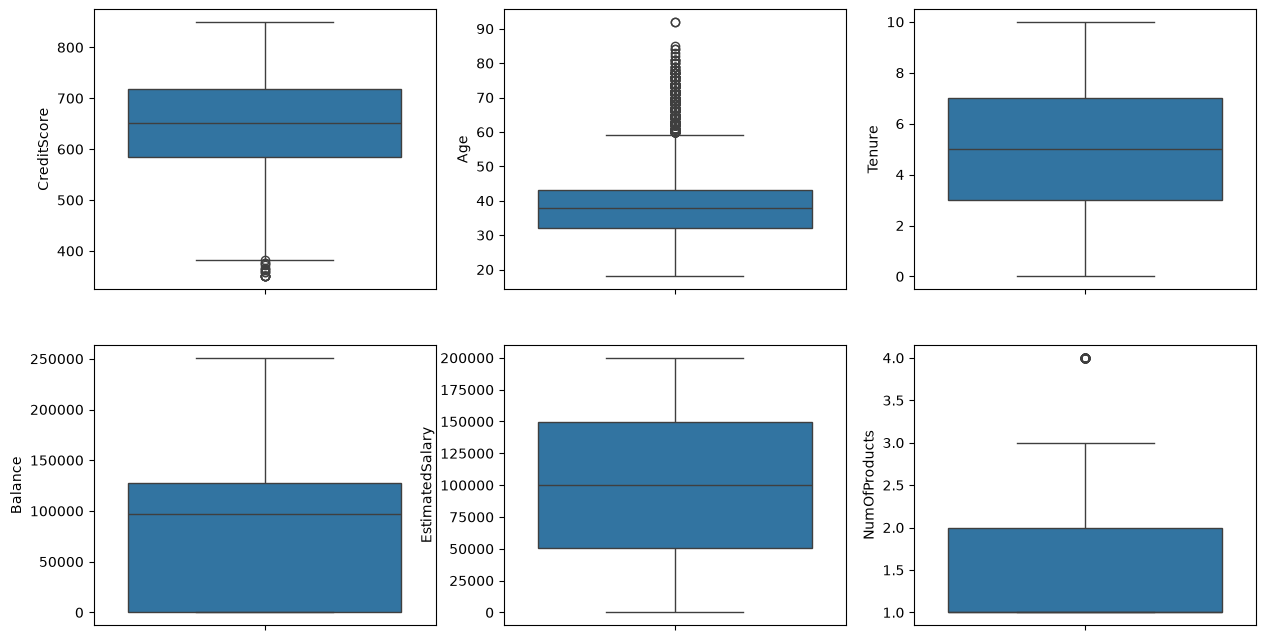

In [19]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
numerical_columns = ["Age", "Tenure", "Balance", "EstimatedSalary", "CreditScore", "NumOfProducts"]

sns.boxplot(data=df['CreditScore'], ax=axes[0,0])
sns.boxplot(data=df['Age'], ax=axes[0,1])
sns.boxplot(data=df['Tenure'], ax=axes[0,2])
sns.boxplot(data=df['Balance'], ax=axes[1,0])
sns.boxplot(data=df['EstimatedSalary'], ax=axes[1,1])
sns.boxplot(data=df['NumOfProducts'], ax=axes[1,2])

plt.show()

#### 3.3 Empirical Rule

In [20]:
def find_anomaly(data):
    mean = data.mean()
    std = data.std()

    upper_bound = mean + (3 * std)
    lower_bound = mean - (3 * std)

    return (data > upper_bound) | (data < lower_bound)

In [26]:
numerical_columns = ["Age", "Tenure", "Balance", "EstimatedSalary", "CreditScore"]

for col in numerical_columns:
    n_outliers = find_anomaly(df[col]).sum()
    n_outlier_percentage = round(n_outliers / len(df), 3)
    print(f"{col}: {n_outliers} outliers ({n_outlier_percentage} %)")

Age: 144 outliers (0.014 %)
Tenure: 0 outliers (0.0 %)
Balance: 0 outliers (0.0 %)
EstimatedSalary: 0 outliers (0.0 %)
CreditScore: 8 outliers (0.001 %)


#### 3.4 IQR Method

In [27]:
def find_anomaly(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    return (data > upper_bound) | (data < lower_bound)

In [28]:
numerical_columns = ["Age", "Tenure", "Balance", "EstimatedSalary", "CreditScore"]

for col in numerical_columns:
    n_outliers = find_anomaly(df[col]).sum()
    n_outlier_percentage = round(n_outliers / len(df), 3)
    print(f"{col}: {n_outliers} outliers ({n_outlier_percentage} %)")

Age: 501 outliers (0.05 %)
Tenure: 0 outliers (0.0 %)
Balance: 0 outliers (0.0 %)
EstimatedSalary: 0 outliers (0.0 %)
CreditScore: 15 outliers (0.002 %)


In [30]:
df.to_csv("./data/processed/ChurnModeling_Outlier_Handled.csv", index=False)